# Integrate (batch correct) single cell datasets with scanpy and scvi-tools

## load required packages

In [4]:
import scanpy as sc
from pathlib import Path
import scvi
import anndata as ad
import re
import pandas as pd
import matplotlib.pyplot as plt


## load cellranger output directories for all samples

In [8]:
sc.read_mtx?

Signature: sc.read_mtx(filename: 'PathLike[str] | str', dtype: 'str' = 'float32') -> 'AnnData'
Docstring:
Read `.mtx` file.

Parameters
----------
filename
    The filename.
dtype
    Numpy data type.
File:      /opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_io/read.py
Type:      function

In [7]:
# Create a Path object for the directory
directory_path = Path('/dfs9/ucightf-lab/projects/LaSpA/250716_0725Bio-04_LaSpA_Parse-WT-100K/Trailmaker_results/all-sample') 
for mydir in directory_path.glob('**/*filtered_feature_bc_matrix*'):
    print(mydir)

In [ ]:
# Use glob() to get a list of all files in the directory
# The '*' wildcard matches any filename

adatas = []
for i, out_dir in enumerate(directory_path.glob('**/*filtered_feature_bc_matrix*')):
    if out_dir.is_dir():
        sample_id = re.search("(?<=/CellRanger/)([^/]+)(?=/outs/)", str(out_dir)).group(1)
        adata = sc.read_10x_mtx(out_dir,
                               var_names="gene_symbols",
                               cache=True)
        adata.obs["batch"] = sample_id
        adatas.append(adata)

## Define a function to preprocess our anndata objects

In [4]:
def sc_preprocess(adata, min_genes=200, min_cells=3, n_top_genes=2000, batch_key='batch', inplace=True):
    """
    Performs standard Scanpy preprocessing on an AnnData object.

    Args:
        adata (anndata.AnnData): The AnnData object to preprocess.
        min_genes (int): Minimum number of genes expressed per cell to pass filtering.
        min_cells (int): Minimum number of cells a gene must be expressed in to pass filtering.
        n_top_genes (int): Number of highly variable genes to select.
        batch_key (str): The key in `adata.obs` that stores batch information.
    """

    if not inplace:
        adata = adata.copy()
    
    # 1. Ensure no duplicate gene symbols
    adata.var_names_make_unique()

    # 2. Quality Control and Filtering
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_genes(adata, min_cells=min_cells)

    # 3. Normalization and Log-Transformation
    adata.raw = adata
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # 4. Highly Variable Genes
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, subset=True)

    sc.pp.neighbors(adata)
    
    sc.tl.umap(adata)
    
    # Perform clustering (if not already done)
    sc.tl.leiden(adata, resolution=0.7)
    
    # Find marker genes for each cluster
    sc.tl.rank_genes_groups(adata, groupby="leiden", method='wilcoxon')
    
    return adata

## Run pre-processing on our anndata objects

In [5]:
for adata in adatas:
    sc_preprocess(adata)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/tmp/ipykernel_3566000/342070812.py:39: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.7)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/apps/python/3.10.2/lib/python3.10/site-packages/sca

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/apps/python/3.10.2/lib/python3.10/site-packages/s

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/apps/python/3.10.2/lib/python3.10/site-packages/s

## verify that the batch variable is appended into cell-level metadata

In [7]:
adatas[0].obs.columns

Index(['batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt',
       'pct_counts_mt', 'n_genes', 'leiden'],
      dtype='object')

## glue every sample together with the `concat` command

In [4]:
combined_adata = ad.concat(adatas, 
                           join='outer',
                           uns_merge="first")

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
# Ensure there are no duplicate gene symbols
combined_adata.var_names_make_unique()

## 1. Quality Control and Filtering

In [10]:
# Assume adata is your loaded AnnData object
# Calculate QC metrics
combined_adata.var['mt'] = combined_adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(combined_adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Filter cells and genes based on your QC plots
sc.pp.filter_cells(combined_adata, min_genes=200)
sc.pp.filter_genes(combined_adata, min_cells=3)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 2. Normalization and Log-Transformation

In [12]:
# Store raw counts before normalization and transformation
combined_adata.raw = combined_adata

# Normalize to a total count of 10,000 per cell
sc.pp.normalize_total(combined_adata, target_sum=1e4)

# Log-transform the data
sc.pp.log1p(combined_adata)

In [13]:
# Preprocessing with Scanpy
sc.pp.highly_variable_genes(
    combined_adata,
    n_top_genes=2000,
    subset=True,
    batch_key="batch",
)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## establish an scvi model for integration using the 'batch' variable

In [14]:
scvi.model.SCVI.setup_anndata(
    combined_adata,
    batch_key="batch",
)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


## train the integration model 
expect this step to take a while ~ 30 min.

In [15]:
model = scvi.model.SCVI(combined_adata)
model.train()

/opt/apps/python/3.10.2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /opt/apps/python/3.10.2/lib/python3.10/site-package ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/apps/python/3.10.2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /opt/apps/python/3.10.2/lib/python3.10/site-package ...


Training:   0%|          | 0/303 [00:00<?, ?it/s]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/opt/apps/python/3.10.2/lib/python3.10/site-packages/scvi/module

## store the integrated model within our combined object

In [17]:
combined_adata.obsm["X_scvi"] = model.get_latent_representation()

## save this intermediate integrated data

In [18]:
combined_adata.write("/dfs9/ucightf-lab/kstachel/scRNAseq_Pipeline/python/combined_250721_0725Bio-05_HughC_10x3v4_GEX_anndata.h5ad")


!stopping point 1

# load our integrated data

In [3]:
combined_adata = sc.read_h5ad("/dfs9/ucightf-lab/kstachel/scRNAseq_Pipeline/python/combined_250721_0725Bio-05_HughC_10x3v4_GEX_anndata.h5ad")

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## Reduce dimensions of our integrated data

In [4]:
sc.pp.neighbors(combined_adata, use_rep="X_scvi")

sc.tl.umap(combined_adata)

# View our integrated dataset

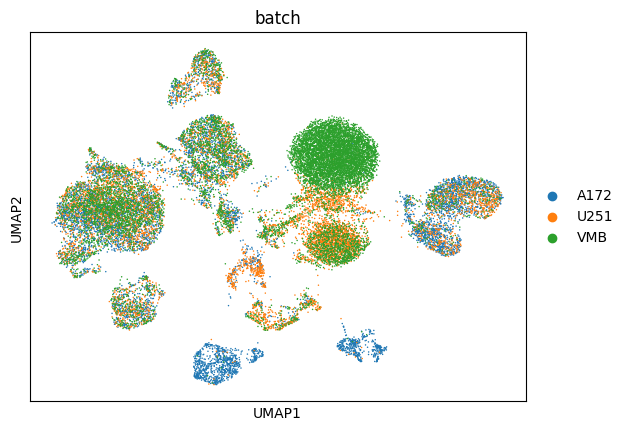

In [5]:
sc.pl.umap(combined_adata, color=["batch"])

## Cluster and find marker genes for our integrated data

In [6]:
# Perform clustering (if not already done)
sc.tl.leiden(combined_adata, key_added='leiden_integrated', resolution=0.7)

# Find marker genes for each cluster
sc.tl.rank_genes_groups(combined_adata, 'leiden_integrated', method='wilcoxon')

/tmp/ipykernel_2503413/3088283644.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(combined_adata, key_added='leiden_integrated', resolution=0.7)


In [7]:
# Access the marker genes
marker_genes_df = pd.DataFrame(combined_adata.uns['rank_genes_groups']['names'])

In [8]:
marker_genes_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,MT2A,CTSK,MTRNR2L12,TENM3,ICAM2,DOCK4,EPS8,CCDC102B,TPT1,LINC02476,PTN,PRKG1,SOX11,LGALS1,CD70,NKD1,SYNDIG1
1,TFPI2,AKR1C2,MT-ND2,RBP1,CLEC14A,LDB2,ZIC1,COL6A3,RPL6,AL117329.1,LRP1B,SOX5,MAP2,GSTT2B,IL18,SKAP1,TRPM3
2,COL3A1,TBX3,MT-ND5,ITGB8,PECAM1,UTRN,ITGA11,MEIS1,RPS6,MIR548XHG,SLC1A3,PTPRG,DCX,TPM2,OCIAD2,MACC1,CA12
3,FN1,LRRK2,MT-CO1,IRX2,TMSB4X,CALCRL,EBF1,POSTN,RPL13,AL713998.1,FABP7,FTX,PAK3,RAB3B,MTHFD2L,DMKN,TPD52L1
4,EEF1A1,ITGBL1,MT-ND4L,NLGN4X,CLDN5,PLEKHG1,FN1,MME,EEF1A1,AC090502.1,SOX2,STARD13,KIF5C,SERINC2,LYPD1,LINC00355,ITGA8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29580,POLR2J3-1,SLC22A23,ZBTB20,SRGN,AREG,TPT1,NRG1,MT-ND2,MBD5,COL1A2,IGFBP4,RPLP1,FTL,PSAP,COL1A1,COL5A2,GNG11
29581,UPF2,ANXA2,PSD3,STC1,COL6A1,B2M,HOXB3,CPNE8,ZBTB20,IGFBP5,MT-CO3,RPS8,IGFBP4,MT-ND4L,DCN,VIM,HOXB3
29582,AP2A2,TENM3,PDE4D,GNG11,COL1A1,EEF1A1,MEIS1,B2M,FTX,CALD1,MT-ND1,TPT1,B2M,IGFBP5,MMP2,IGFBP4,STC1
29583,GON4L,FABP5,NEAT1,COL3A1,COL1A2,FTL,CLU,CLU,MALAT1,FN1,MT-ND4,EEF1A1,FN1,MT-CO1,COL4A1,FN1,MEIS2


In [ ]:
# # Manually annotate clusters based on marker genes and biological knowledge
# # Create a dictionary mapping cluster IDs to cell type names
# cell_type_mapping = {
#     '0': 'T cells',
#     '1': 'B cells',
#     '2': 'Macrophages',
#     # Add more mappings for other clusters
# }

# # Add a new observation column for cell type annotation
# combined_adata.obs['cell_type'] = combined_adata.obs['leiden'].map(cell_type_mapping)

# # Visualize the annotated clusters
# sc.pl.umap(combined_adata, color='cell_type', legend_loc='on data')

In [17]:
?sc.pl.rank_genes_groups_heatmap

Signature:
sc.pl.rank_genes_groups_heatmap(
    adata: 'AnnData',
    groups: 'str | Sequence[str] | None' = None,
    *,
    n_genes: 'int | None' = None,
    groupby: 'str | None' = None,
    gene_symbols: 'str | None' = None,
    var_names: 'Sequence[str] | Mapping[str, Sequence[str]] | None' = None,
    min_logfoldchange: 'float | None' = None,
    key: 'str | None' = None,
    show: 'bool | None' = None,
    save: 'bool | None' = None,
    **kwds,
)
Docstring:
Plot ranking of genes using heatmap plot (see :func:`~scanpy.pl.heatmap`).

Parameters
----------
adata
    Annotated data matrix.
groups
    The groups for which to show the gene ranking.
n_genes
    Number of genes to show. This can be a negative number to show for
    example the down regulated genes. eg: num_genes=-10. Is ignored if
    `gene_names` is passed.
gene_symbols
    Column name in `.var` DataFrame that stores gene symbols. By default `var_names`
    refer to the index column of the `.var` DataFrame. Setting th

## View a clustered heatmap of marker genes for each cluster 

{'heatmap_ax': <Axes: >,
 'groupby_ax': <Axes: ylabel='leiden_integrated'>,
 'dendrogram_ax': <Axes: >,
 'gene_groups_ax': <Axes: >}

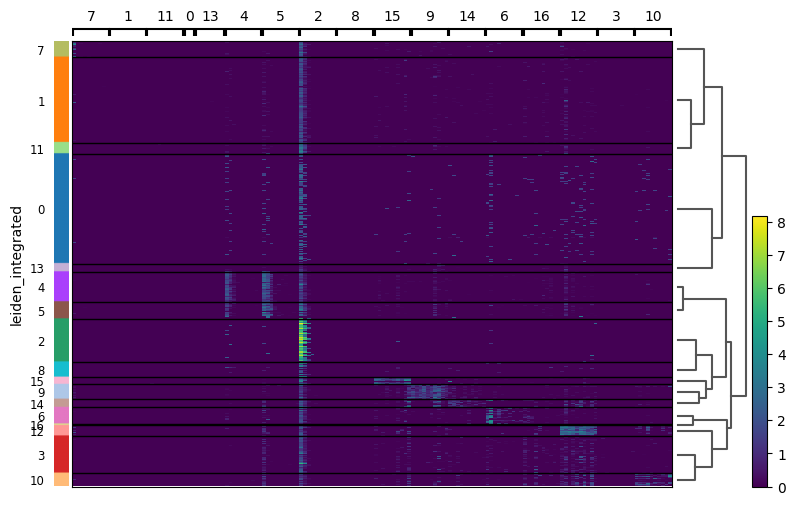

In [30]:
sc.pl.rank_genes_groups_heatmap(combined_adata, 
                                groupby='leiden_integrated', 
                                n_genes=10, 
                                show=False,
                                min_logfoldchange=5)


#  Stacked Bar Plot of cluster membership by batch

## View the distribution of batches across clusters to get a sense of any sample-specific cell types/states

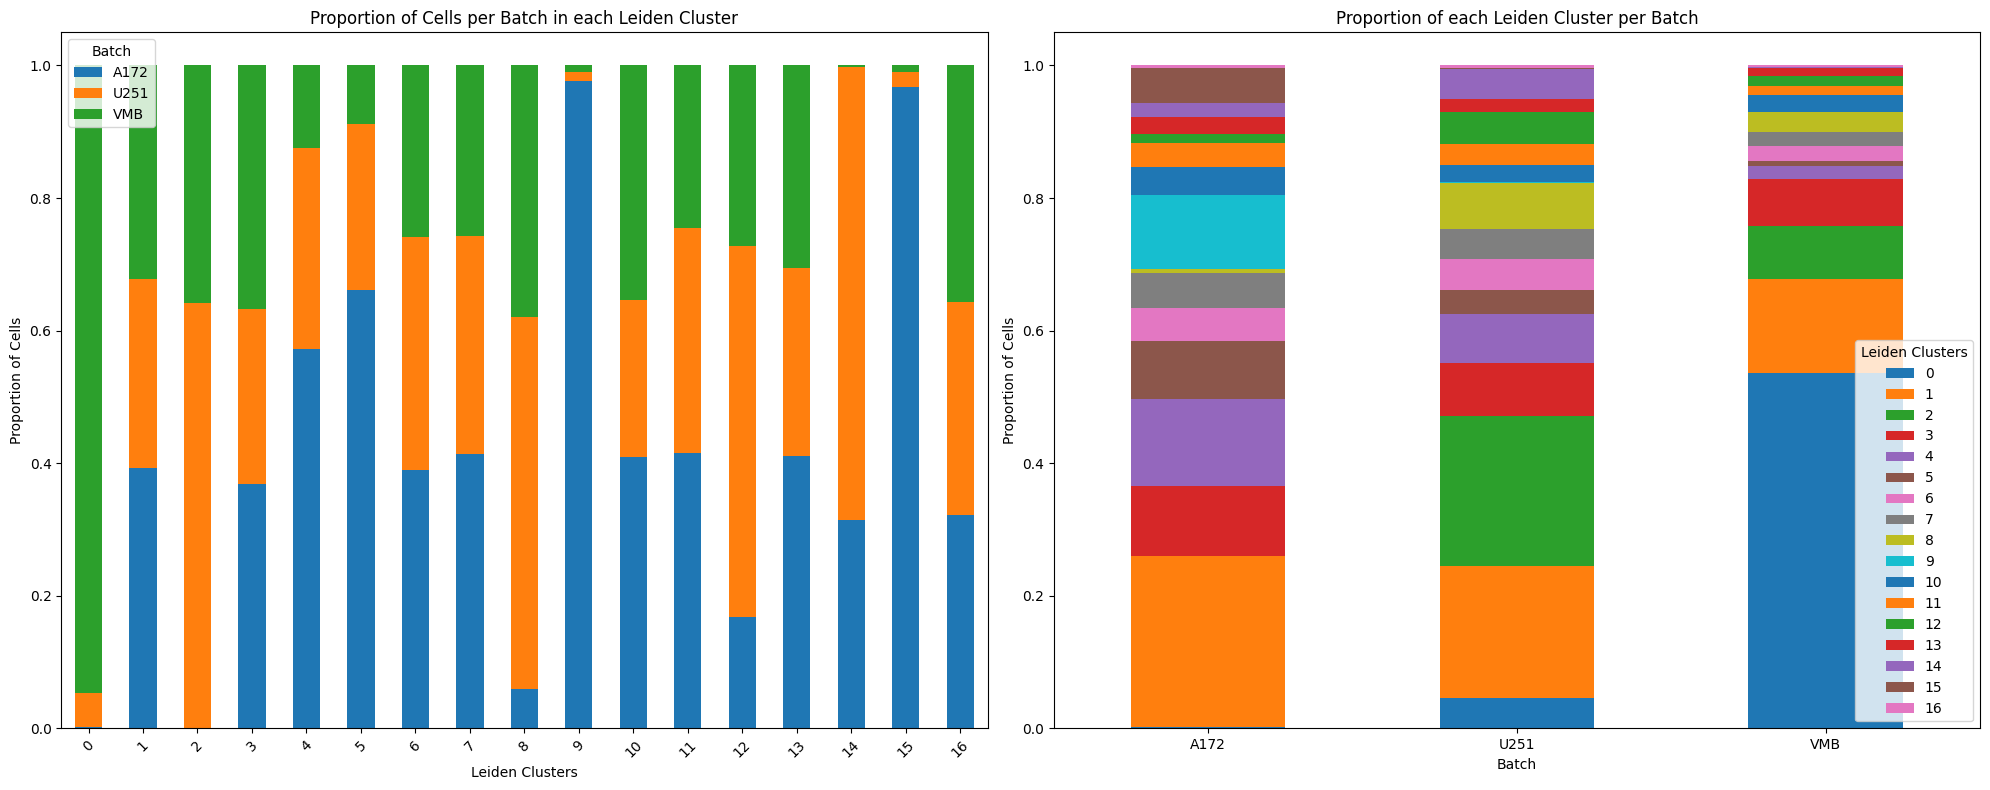

In [11]:
# Create the two cross-tabulation dataframes
crosstab_df_1 = pd.crosstab(combined_adata.obs['leiden_integrated'], combined_adata.obs['batch'], normalize='index')
crosstab_df_2 = pd.crosstab(combined_adata.obs['batch'], combined_adata.obs['leiden_integrated'], normalize='index')

# Set up the subplot figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=False) # Use sharey=True if you want the same y-axis scale

# Plot the first cross-tabulation on the first axis
crosstab_df_1.plot(kind='bar', stacked=True, ax=ax1)
ax1.set_title('Proportion of Cells per Batch in each Leiden Cluster')
ax1.set_xlabel('Leiden Clusters')
ax1.set_ylabel('Proportion of Cells')
ax1.legend(title='Batch')
ax1.tick_params(axis='x', rotation=45)

# Plot the second cross-tabulation on the second axis
crosstab_df_2.plot(kind='bar', stacked=True, ax=ax2)
ax2.set_title('Proportion of each Leiden Cluster per Batch')
ax2.set_xlabel('Batch')
ax2.set_ylabel('Proportion of Cells')
ax2.legend(title='Leiden Clusters')
ax2.tick_params(axis='x', rotation=0)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()